## Fase 1: Extracción de Datos Inmobiliarios con Playwright

In [27]:
from playwright.async_api import async_playwright
from pymongo import MongoClient, UpdateOne
import datetime
import random
import re

print("🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...")

cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica'] 

colonias_objetivo = {
    "Condesa": "condesa", "Roma Norte": "roma-norte", "Roma Sur": "roma-sur",
    "Doctores": "doctores", "Del Valle": "del-valle", "Narvarte": "narvarte",
    "Polanco": "polanco", "Coyoacán": "coyoacan", "Santa Fe": "santa-fe",
    "Lomas de Chapultepec": "lomas-de-chapultepec", "San Rafael": "san-rafael",
    "Santa María la Ribera": "santa-maria-la-ribera", "Centro": "centro",
    "Escandón": "escandon", "Portales": "portales"
}

playwright = await async_playwright().start()
browser = await playwright.chromium.launch(
    headless=False,
    args=["--disable-blink-features=AutomationControlled"]
)

contexto = await browser.new_context(viewport={"width": 1366, "height": 768})
page = await contexto.new_page()
await page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

for nombre_colonia, slug in colonias_objetivo.items():
    for pagina in range(1, 4):
        url = f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}.html" if pagina == 1 else f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}-pagina-{pagina}.html"
            
        print(f"⚡ {nombre_colonia} | Pág {pagina}...", end=" ")
        
        try:
            await page.goto(url, timeout=60000)
            
            # Tiempos de espera reducidos pero realistas para evitar el WAF
            await page.wait_for_timeout(random.randint(4000, 7000))
            
            for _ in range(3):
                await page.mouse.wheel(0, 1500)
                await page.wait_for_timeout(1000)
            
            tarjetas = await page.locator("div[class*='postingCard'], div[class*='PostingCard']").all()
            registros_extraidos = []
            
            for tarjeta in tarjetas: 
                try:
                    texto_completo = await tarjeta.inner_text()
                    texto_limpio = texto_completo.lower().replace("\n", " ")
                    
                    # 🧬 REGEX: Precio
                    match_precio = re.search(r'mn\s*([\d,]+)', texto_limpio) or re.search(r'\$\s*([\d,]+)', texto_limpio)
                    if not match_precio: continue
                    precio_numerico = int(match_precio.group(1).replace(',', ''))
                    
                    # 🧬 REGEX: Metros Cuadrados (busca variaciones como 120 m², 120m2, etc.)
                    match_metros = re.search(r'(\d+)\s*(?:m²|m2|m c)', texto_limpio)
                    metros_cuadrados = int(match_metros.group(1)) if match_metros else None
                    
                    # 🧬 REGEX: Recámaras
                    match_recamaras = re.search(r'(\d+)\s*rec', texto_limpio)
                    recamaras = int(match_recamaras.group(1)) if match_recamaras else None
                    
                    titulo = texto_completo.split('\n')[0].strip()[:100]
                    
                    # Solo guardamos el dato si logramos extraer precio y metros cuadrados
                    if metros_cuadrados and precio_numerico: 
                        registros_extraidos.append({
                            "titulo": titulo, 
                            "precio_numerico": precio_numerico,
                            "metros_cuadrados": metros_cuadrados,
                            "recamaras": recamaras,
                            "colonia": nombre_colonia, 
                            "fecha_extraccion": datetime.datetime.now().strftime("%Y-%m-%d")
                        })
                except:
                    continue

            if registros_extraidos:
                operaciones_db = [UpdateOne({"titulo": r["titulo"], "colonia": r["colonia"]}, {"$set": r}, upsert=True) for r in registros_extraidos]
                coleccion.bulk_write(operaciones_db)
                print(f"✅ {len(registros_extraidos)} guardados.")
            else:
                print("⚠️ Sin datos útiles (¿Captcha?).")
                
        except Exception as e:
            print("❌ Error de carga.")

print("\n📊 Total con Analítica Avanzada ('departamentos_analitica'):", coleccion.count_documents({}))
await browser.close()
await playwright.stop()

🚀 Iniciando motor de extracción (Modo Equilibrado + Regex)...
⚡ Condesa | Pág 1... ✅ 120 guardados.
⚡ Condesa | Pág 2... ✅ 120 guardados.
⚡ Condesa | Pág 3... ✅ 120 guardados.
⚡ Roma Norte | Pág 1... ✅ 116 guardados.
⚡ Roma Norte | Pág 2... ✅ 116 guardados.
⚡ Roma Norte | Pág 3... ✅ 116 guardados.
⚡ Roma Sur | Pág 1... ✅ 116 guardados.
⚡ Roma Sur | Pág 2... ✅ 116 guardados.
⚡ Roma Sur | Pág 3... ✅ 116 guardados.
⚡ Doctores | Pág 1... ✅ 120 guardados.
⚡ Doctores | Pág 2... ✅ 8 guardados.
⚡ Doctores | Pág 3... ✅ 8 guardados.
⚡ Del Valle | Pág 1... ✅ 120 guardados.
⚡ Del Valle | Pág 2... ✅ 120 guardados.
⚡ Del Valle | Pág 3... ✅ 116 guardados.
⚡ Narvarte | Pág 1... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 2... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Narvarte | Pág 3... ⚠️ Sin datos útiles (¿Captcha?).
⚡ Polanco | Pág 1... ✅ 120 guardados.
⚡ Polanco | Pág 2... ✅ 112 guardados.
⚡ Polanco | Pág 3... ✅ 120 guardados.
⚡ Coyoacán | Pág 1... ✅ 120 guardados.
⚡ Coyoacán | Pág 2... ✅ 120 guard

## Fase 2: Limpieza, Casteo de Tipos y Feature Engineering

In [60]:
import pandas as pd
from pymongo import MongoClient

print("🔌 Extrayendo datos de la bóveda analítica...")

# 1. Conexión y Extracción a Pandas
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_analitica']
df = pd.DataFrame(list(coleccion.find()))

if '_id' in df.columns:
    df = df.drop(columns=['_id'])

# 2. Ingeniería de Características y Limpieza Básica
df = df.dropna(subset=['precio_numerico', 'metros_cuadrados']).copy()
df['precio_por_m2'] = df['precio_numerico'] / df['metros_cuadrados']

# 3. 🧹 FILTROS ESTRICTOS DE CALIDAD DE DATOS (Data Quality)
# Quitar títulos basura (+fotos, USD)
df = df[~df['titulo'].str.contains(r'\+|\bUSD\b', na=False, regex=True)].copy()

# Quitar precios absurdos y tamaños irreales
df = df[
    (df['precio_por_m2'] > 50) & 
    (df['precio_numerico'] >= 3000) & 
    (df['metros_cuadrados'] < 500)
].copy()

print(f"✅ Fase 2 completada: {len(df)} registros limpios y validados listos para análisis.")
display(df[['titulo', 'colonia', 'precio_numerico', 'metros_cuadrados', 'precio_por_m2']].head(3))

🔌 Extrayendo datos de la bóveda analítica...
✅ Fase 2 completada: 519 registros limpios y validados listos para análisis.


,titulo,colonia,precio_numerico,metros_cuadrados,precio_por_m2
1,"MN 27,500",Condesa,27500,80,343.750000
3,"MN 67,000",Condesa,67000,140,478.571429
5,"MN 25,150",Condesa,25150,42,598.809524


## Fase 3: Radiografía del Mercado y Análisis de Costo-Beneficio

In [61]:
print("📊 Calculando métricas de dispersión y promedios...")

# 3. Análisis Estadístico por Colonia
estadisticas = df.groupby('colonia').agg(
    total_anuncios=('titulo', 'count'),
    precio_min=('precio_numerico', 'min'),
    precio_max=('precio_numerico', 'max'),
    precio_promedio=('precio_numerico', 'mean'),
    precio_mediano=('precio_numerico', 'median'),
    m2_promedio=('metros_cuadrados', 'mean'),
    precio_m2_promedio=('precio_por_m2', 'mean')
).round(2).reset_index()

# 4. Algoritmo de Costo-Beneficio
# Filtramos colonias con al menos 5 anuncios para evitar sesgos estadísticos
# y las ordenamos de MENOR a MAYOR precio por metro cuadrado.
colonias_confiables = estadisticas[estadisticas['total_anuncios'] >= 5]
top_costo_beneficio = colonias_confiables.sort_values(by='precio_m2_promedio', ascending=True)

print("🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):")
display(top_costo_beneficio[['colonia', 'precio_m2_promedio', 'm2_promedio', 'precio_mediano']].head(3))

print("\n📈 RADIOGRAFÍA DEL MERCADO (Mínimos y Máximos):")
display(estadisticas[['colonia', 'precio_min', 'precio_max', 'precio_promedio', 'total_anuncios']])

📊 Calculando métricas de dispersión y promedios...
🏆 TOP 3 MEJORES COLONIAS (Costo-Beneficio por m²):


,colonia,precio_m2_promedio,m2_promedio,precio_mediano
6,Lomas de Chapultepec,327.02,230.87,67000.0
5,Escandón,334.37,144.94,35000.0
4,Doctores,340.34,62.97,20900.0



📈 RADIOGRAFÍA DEL MERCADO (Mínimos y Máximos):


,colonia,precio_min,precio_max,precio_promedio,total_anuncios
0,Centro,4500,55000,13916.67,12
1,Condesa,9500,195000,46562.16,56
2,Coyoacán,9800,4950000,113457.33,57
3,Del Valle,10500,250000,54220.00,50
4,Doctores,6800,40000,21293.55,31
5,Escandón,5500,200000,47990.58,65
6,Lomas de Chapultepec,10500,150000,70864.44,45
7,Polanco,20000,230000,75333.33,51
8,Roma Norte,14500,60000,29893.33,30
9,Roma Sur,14500,60000,29893.33,30


## Fase 4: Renderizado Cartográfico Interactivo

In [62]:
import geopandas as gpd
import folium
import mapclassify
import unicodedata
import os
import urllib.request
import matplotlib.pyplot as plt

print("🗺️ Preparando el motor geoespacial...")

# Archivo de destino local
archivo_geojson = "colonias_cdmx.geojson"
# La liga directa y oficial que obtuviste del portal de la CDMX
url_mapa = "https://datos.cdmx.gob.mx/dataset/04a1900a-0c2f-41ed-94dc-3d2d5bad4065/resource/8070ee81-9111-437e-a3dd-0c3cc6dce9f4/download/8070ee81-9111-437e-a3dd-0c3cc6dce9f4.json"

# Automatizamos la descarga directa al disco duro
if not os.path.exists(archivo_geojson):
    print("📥 Descargando polígonos oficiales de la CDMX (esto puede tomar unos segundos)...")
    urllib.request.urlretrieve(url_mapa, archivo_geojson)
    print("✅ Descarga completada.")
else:
    print("✅ El mapa base ya está guardado en tu carpeta local.")

print("🧠 Extrayendo coordenadas geométricas a la memoria...")
mapa_cdmx = gpd.read_file(archivo_geojson)

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

# Normalizamos nuestras zonas
estadisticas['llave_cruce'] = estadisticas['colonia'].apply(normalizar_texto)
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)

# Creamos una columna vacía para guardar los precios
mapa_cdmx['precio_asignado'] = pd.NA

# El Cruce Inteligente (Substring Mapping)
colonias_encontradas = 0
for index, row in estadisticas.iterrows():
    zona_extraida = row['llave_cruce']
    precio_mediano = row['precio_mediano']
    
    mascara = mapa_cdmx['llave_oficial'].str.contains(zona_extraida, na=False)
    
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = precio_mediano
        colonias_encontradas += 1

print(f"🔗 Se inyectaron precios en {colonias_encontradas} polígonos del mapa.")

# Hacemos una copia limpia de los datos que sí cruzaron
zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])

print("🌐 Construyendo el mapa interactivo web...")

# Proyección Cartográfica
zonas_calientes = zonas_calientes.to_crs(epsg=4326)

# Ingeniería de Características visual
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

# Renderizado Interactivo (Folium Engine con Servidores Esri)
mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    legend_kwds={"caption": "Mediana de Renta Mensual (MXN)"},
    style_kwds={"color": "black", "weight": 1, "fillOpacity": 0.8} 
)

# Exportación
archivo_salida = "mapa_inmobiliario_cdmx.html"
mapa_interactivo.save(archivo_salida)
print(f"✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como '{archivo_salida}'.")

mapa_interactivo

🗺️ Preparando el motor geoespacial...
✅ El mapa base ya está guardado en tu carpeta local.
🧠 Extrayendo coordenadas geométricas a la memoria...
🔗 Se inyectaron precios en 12 polígonos del mapa.
🌐 Construyendo el mapa interactivo web...
✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como 'mapa_inmobiliario_cdmx.html'.


🔌 Conectando a la nueva bóveda masiva de MongoDB...
🧠 Cruzando 705 registros con los polígonos del gobierno...
  ✅ CENTRO: Asignado a 16 subdivisiones.
  ✅ CONDESA: Asignado a 2 subdivisiones.
  ✅ COYOACAN: Asignado a 9 subdivisiones.
  ✅ DEL VALLE: Asignado a 10 subdivisiones.
  ✅ DOCTORES: Asignado a 5 subdivisiones.
  ✅ ESCANDON: Asignado a 2 subdivisiones.
  ✅ LOMAS DE CHAPULTEPEC: Asignado a 6 subdivisiones.
  ✅ POLANCO: Asignado a 9 subdivisiones.
  ✅ ROMA NORTE: Asignado a 3 subdivisiones.
  ✅ ROMA SUR: Asignado a 2 subdivisiones.
  ✅ SANTA FE: Asignado a 6 subdivisiones.
  ✅ SANTA MARIA LA RIBERA: Asignado a 3 subdivisiones.

🎨 Renderizando el mapa con la nueva densidad de datos...


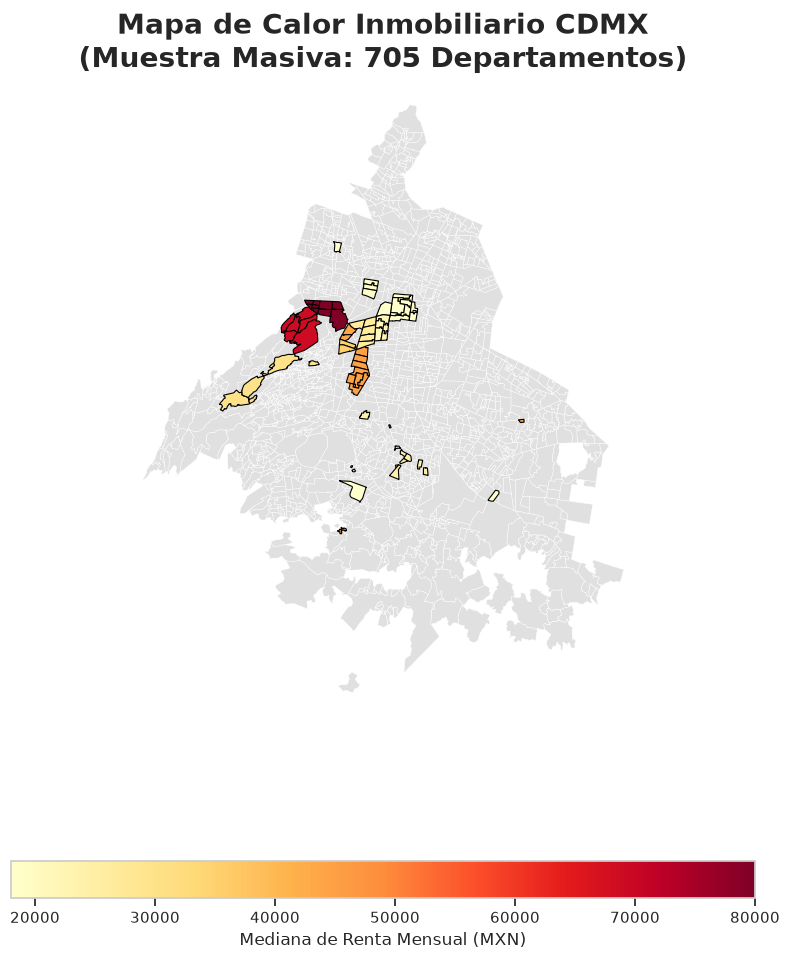

In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pymongo import MongoClient
import unicodedata

print("🔌 Conectando a la nueva bóveda masiva de MongoDB...")

# 1. Extracción apuntando a la NUEVA colección
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_masivo']
df = pd.DataFrame(list(coleccion.find()))

# Limpieza y conversión a números
df['precio_numerico'] = df['precio_raw'].str.replace('MN', '', regex=False)
df['precio_numerico'] = df['precio_numerico'].str.replace(',', '', regex=False).str.strip()
df['precio_numerico'] = pd.to_numeric(df['precio_numerico'], errors='coerce')

# 2. Agrupación Estadística (Mediana)
df_estadisticas = df.groupby('colonia')['precio_numerico'].median().reset_index()

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

df_estadisticas['llave_cruce'] = df_estadisticas['colonia'].apply(normalizar_texto)

print(f"🧠 Cruzando {len(df)} registros con los polígonos del gobierno...")

# 3. Preparamos el mapa oficial
mapa_cdmx = gpd.read_file("colonias_cdmx.geojson")
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)
mapa_cdmx['precio_asignado'] = pd.NA

# 4. El Cruce Inteligente (Substring Mapping)
colonias_encontradas = 0
for index, row in df_estadisticas.iterrows():
    zona_extraida = row['llave_cruce']
    precio_mediano = row['precio_numerico']
    
    mascara = mapa_cdmx['llave_oficial'].str.contains(zona_extraida, na=False)
    
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = precio_mediano
        colonias_encontradas += 1
        print(f"  ✅ {zona_extraida}: Asignado a {mascara.sum()} subdivisiones.")

print(f"\n🎨 Renderizando el mapa con la nueva densidad de datos...")

# 5. Visualización
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
mapa_cdmx.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.3)

# Hacemos una copia limpia de los datos que sí cruzaron
zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()

# ⬅️ EL PARCHE: Forzamos matemáticamente la columna a formato numérico (float64)
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])

# Ahora GeoPandas detectará que son números y creará una barra de color (colorbar) correctamente
zonas_calientes.plot(
    column='precio_asignado', 
    cmap='YlOrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Mediana de Renta Mensual (MXN)", 'orientation': "horizontal", 'shrink': 0.6}
)

ax.set_title('Mapa de Calor Inmobiliario CDMX\n(Muestra Masiva: 705 Departamentos)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
ax.axis('off')
plt.show()

In [64]:
import folium
import mapclassify

print("🌐 Construyendo el mapa interactivo web...")

# 1. Proyección Cartográfica: Aseguramos que el mapa use coordenadas GPS estándar (WGS84)
zonas_calientes = zonas_calientes.to_crs(epsg=4326)

# 2. Ingeniería de Características (Feature Engineering) visual
# Creamos una columna limpia exclusiva para el cuadro de texto (ej. "$ 25,000 MXN")
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

# 3. Renderizado Interactivo (Folium Engine con Servidores Esri)
mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    # ⬅️ EL PARCHE: Conectamos directo al servidor empresarial de Esri
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ", # Requisito legal de atribución
    legend_kwds={"caption": "Mediana de Renta Mensual (MXN)"},
    style_kwds={"color": "black", "weight": 1, "fillOpacity": 0.8} 
)

# 4. Exportación
archivo_salida = "mapa_inmobiliario_cdmx.html"
mapa_interactivo.save(archivo_salida)
print(f"✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como '{archivo_salida}'.")

# 5. Desplegamos el mapa
mapa_interactivo

🌐 Construyendo el mapa interactivo web...
✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como 'mapa_inmobiliario_cdmx.html'.


## Fase 5: Exportación de Snapshot de Datos

In [65]:
print("💾 Iniciando volcado de datos a disco duro...")

# Nombres de los archivos de salida
archivo_crudo = 'dataset_inmobiliario_completo.csv'
archivo_stats = 'estadisticas_por_colonia.csv'

# Exportación a formato CSV (UTF-8 asegura que los acentos como "Coyoacán" se guarden bien)
df.to_csv(archivo_crudo, index=False, encoding='utf-8')
estadisticas.to_csv(archivo_stats, index=False, encoding='utf-8')

print(f"✅ ¡Blindaje completo! Tus datos están a salvo en:")
print(f"   -> {archivo_crudo} (Dataset individual para Machine Learning)")
print(f"   -> {archivo_stats} (Métricas agregadas para Dashboards)")

💾 Iniciando volcado de datos a disco duro...
✅ ¡Blindaje completo! Tus datos están a salvo en:
   -> dataset_inmobiliario_completo.csv (Dataset individual para Machine Learning)
   -> estadisticas_por_colonia.csv (Métricas agregadas para Dashboards)


## Fase 6 Regresion lineal y deteccion de ofertas

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("📈 Fase 6: Detectando propiedades subvaluadas (Algoritmo de Regresión)...")

# 1. Calculamos la línea de regresión teórica (Y_esperado = m * X + b)
m, b = np.polyfit(df['metros_cuadrados'], df['precio_numerico'], 1)
df['precio_esperado'] = (m * df['metros_cuadrados']) + b

# 2. Definimos las "Gangas" matemáticas
df['diferencia_precio'] = df['precio_numerico'] - df['precio_esperado']
gangas = df[df['diferencia_precio'] < -15000].sort_values(by='diferencia_precio', ascending=True)

# --- VISUALIZACIÓN MULTICOLOR ---
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df,
    x='metros_cuadrados',
    y='precio_numerico',
    hue='colonia', 
    palette='tab10', 
    alpha=0.8,
    s=70,
    edgecolor='black',
    linewidth=0.5
)

# Dibujamos la línea de tendencia de referencia
plt.plot(df['metros_cuadrados'], df['precio_esperado'], color='red', linewidth=2, label='Tendencia Esperada (Modelo)')

plt.title('Mapa de Dispersión Categórico: Precios por Colonia vs. Tamaño', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño (m²)', fontsize=14)
plt.ylabel('Renta Mensual (MXN)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Colonias')
plt.tight_layout()
plt.show()

# --- TABLA DE LAS MEJORES OPORTUNIDADES ---
print(f"🎯 Se detectaron {len(gangas)} propiedades genuinamente subvaluadas.")
print("\n🏆 TOP OPORTUNIDADES REALES:")
columnas_interes = ['colonia', 'titulo', 'precio_numerico', 'precio_esperado', 'metros_cuadrados', 'diferencia_precio']
# Redondeamos el precio esperado para que se vea profesional
gangas['precio_esperado'] = gangas['precio_esperado'].round(2)
display(gangas[columnas_interes].head(10))

📈 Fase 6: Detectando propiedades subvaluadas (Algoritmo de Regresión)...


KeyError: 'metros_cuadrados'

## Analisis de dispersion y regresion lineal

📊 Graficando 704 registros limpios (se excluyeron 42 outliers de ruido).


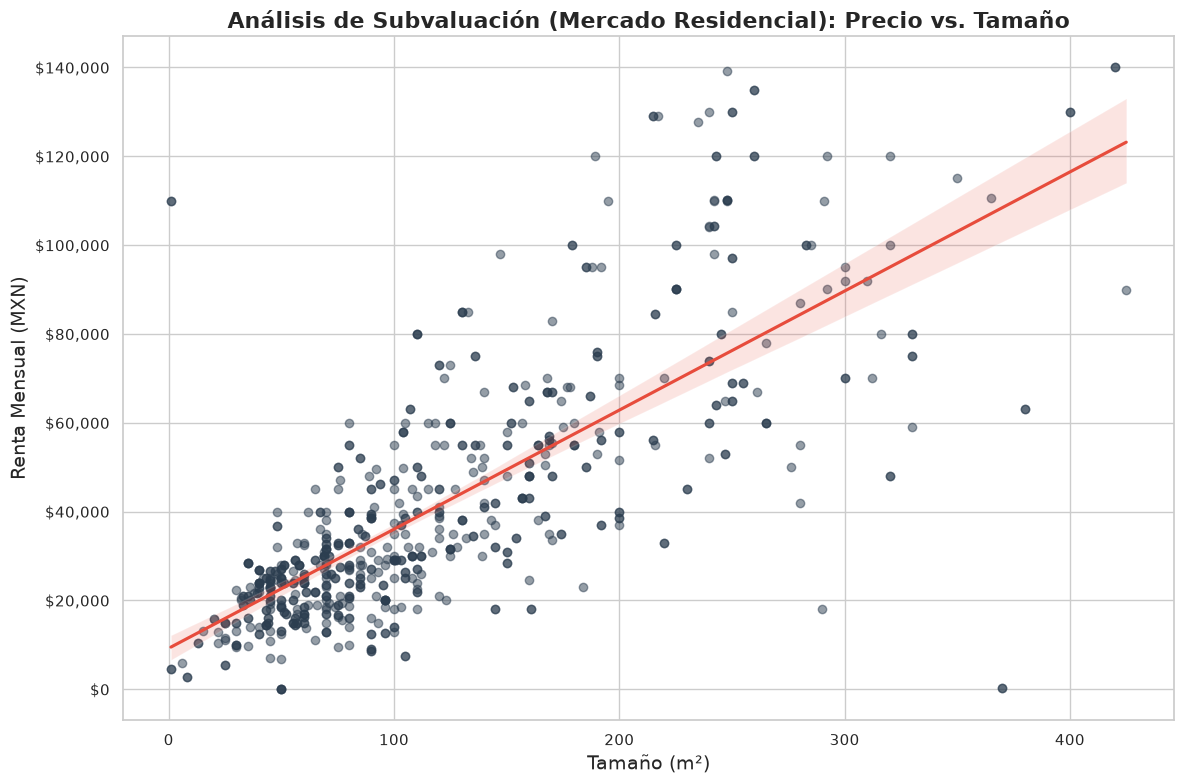

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🧹 Filtramos outliers extremos (ej. rentas mayores a $150,000 MXN o tamaños mayores a 500 m²)
# para aislar el mercado residencial real de departamentos.
df_filtrado = df[(df['precio_numerico'] < 150000) & (df['metros_cuadrados'] < 500)].copy()

print(f"📊 Graficando {len(df_filtrado)} registros limpios (se excluyeron {len(df) - len(df_filtrado)} outliers de ruido).")

fig, ax = plt.subplots(figsize=(12, 8))

# Generamos el diagrama de dispersión con la línea de tendencia (Regresión lineal)
sns.regplot(
    data=df_filtrado,
    x='metros_cuadrados',
    y='precio_numerico',
    scatter_kws={'alpha': 0.5, 'color': '#2C3E50'}, 
    line_kws={'color': '#E74C3C'}, # Línea de tendencia estimada
    ax=ax
)

ax.set_title('Análisis de Subvaluación (Mercado Residencial): Precio vs. Tamaño', fontsize=16, fontweight='bold')
ax.set_xlabel('Tamaño (m²)', fontsize=14)
ax.set_ylabel('Renta Mensual (MXN)', fontsize=14)
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

🎯 Se detectaron 92 propiedades candidatas a 'Gangas' o subvaluadas.


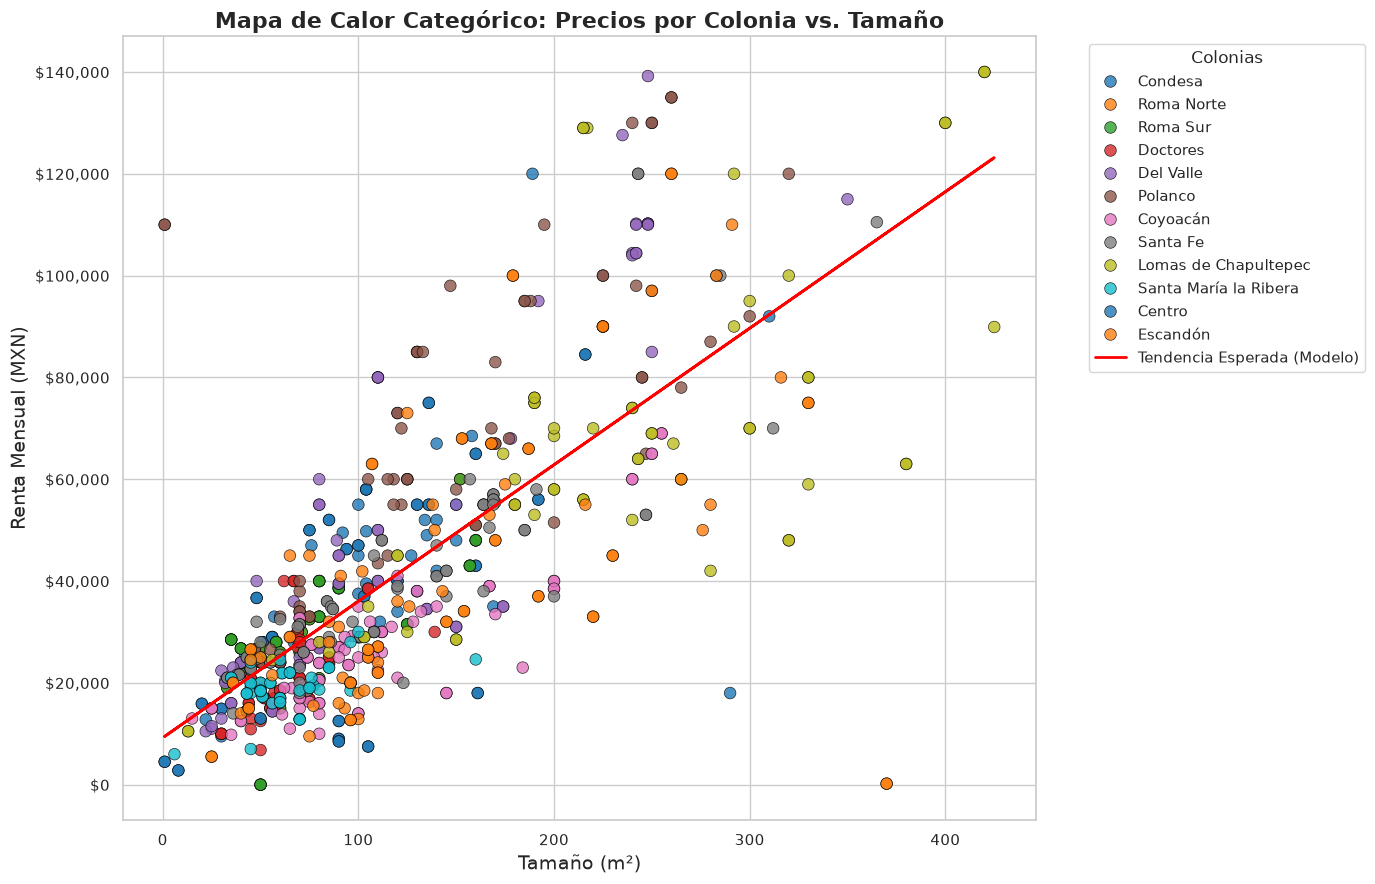


🏆 DATAFRAME DE OPORTUNIDADES (Top Departamentos Subvaluados):


,colonia,titulo,precio_numerico,metros_cuadrados,precio_por_m2,diferencia_precio
729,Escandón,"USD 9,500",200,370,0.540541,-108219.949909
728,Escandón,+23 fotos,200,370,0.540541,-108219.949909
634,Centro,+16 fotos,18000,290,62.068966,-68971.401712
517,Lomas de Chapultepec,+5 fotos,63000,380,165.789474,-48101.018433
570,Lomas de Chapultepec,"MN 63,000",63000,380,165.789474,-48101.018433
516,Lomas de Chapultepec,"MN 48,000",48000,320,150.000000,-47014.607286
513,Lomas de Chapultepec,+17 fotos,48000,320,150.000000,-47014.607286
551,Lomas de Chapultepec,"MN 42,000",42000,280,150.000000,-42290.333187
556,Lomas de Chapultepec,"MN 59,000",59000,330,178.787879,-38695.675810
378,Coyoacán,"MN 23,000",23000,184,125.000000,-35552.075351


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtramos outliers para asegurar la calidad de la regresión
df_filtrado = df[(df['precio_numerico'] < 150000) & (df['metros_cuadrados'] < 500)].copy()

# 2. Calculamos la línea de regresión teórica (Y_esperado = m * X + b)
m, b = np.polyfit(df_filtrado['metros_cuadrados'], df_filtrado['precio_numerico'], 1)
df_filtrado['precio_esperado'] = (m * df_filtrado['metros_cuadrados']) + b

# 3. Definimos la "Gangas" (aquellos cuyo precio real es menor al esperado por el modelo)
# Buscamos los que estén al menos 15,000 MXN por debajo de la línea de tendencia
df_filtrado['diferencia_precio'] = df_filtrado['precio_numerico'] - df_filtrado['precio_esperado']
gangas = df_filtrado[df_filtrado['diferencia_precio'] < -15000].sort_values(by='diferencia_precio', ascending=True)

print(f"🎯 Se detectaron {len(gangas)} propiedades candidatas a 'Gangas' o subvaluadas.")

# --- VISUALIZACIÓN MULTICOLOR ---
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df_filtrado,
    x='metros_cuadrados',
    y='precio_numerico',
    hue='colonia', # ⬅️ Asigna un color único a cada colonia
    palette='tab10', # Paleta de colores distinguible
    alpha=0.8,
    s=70,
    edgecolor='black',
    linewidth=0.5
)

# Dibujamos la línea de tendencia de referencia
plt.plot(df_filtrado['metros_cuadrados'], df_filtrado['precio_esperado'], color='red', linewidth=2, label='Tendencia Esperada (Modelo)')

plt.title('Mapa de Calor Categórico: Precios por Colonia vs. Tamaño', fontsize=16, fontweight='bold')
plt.xlabel('Tamaño (m²)', fontsize=14)
plt.ylabel('Renta Mensual (MXN)', fontsize=14)
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Colonias')
plt.tight_layout()
plt.show()

# --- TABLA APARTE DE LAS MEJORES OPORTUNIDADES ---
print("\n🏆 DATAFRAME DE OPORTUNIDADES (Top Departamentos Subvaluados):")
columnas_interes = ['colonia', 'titulo', 'precio_numerico', 'metros_cuadrados', 'precio_por_m2', 'diferencia_precio']
display(gangas[columnas_interes].head(10))